In [1]:

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')  # Disable GPU temporarily to reconfigure
gpus = tf.config.list_physical_devices('GPU')

import os
import pandas as pd
import librosa 
import numpy as np


# mehrklassen probieren
# loss funktion recherchieren
# verschiedene Window Größen

WINDOW_LENGTH = 1000

data = "./features-relative.csv"
signals_folder = "./Spontanaktivität"
signals = {}

for file in os.listdir(signals_folder):
    file_path = os.path.join(signals_folder, file)
    signal, fs = librosa.load(file_path)
    signals[file] = signal

df = pd.read_csv(data)

labels = {}

for index, row in df.iterrows():
    if str(row["Label"]).lower() in ["fibrillation", "psw"]:
        key = row["file"] 
        item = {"label": row["Label"], "start": row["Start"], "end": row["End"]}

        if key not in labels:
            labels[key] = []

        labels[key].append(item)

2025-11-20 15:26:01.238949: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-20 15:26:01.281486: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## hello


In [2]:
training_df = pd.DataFrame(columns=["file", "segment", "signal", "labels"])

def slice_signal(signal, fs, window_seconds):
    window_len = int(window_seconds * fs)
    slices = []

    for start in range(0, len(signal), window_len):
        end = start + window_len
        chunk = signal[start:end]

        if len(chunk) < window_len:
            padding = window_len - len(chunk)
            chunk = np.pad(chunk, (0, padding))
        
        slices.append(chunk)

    return slices

def generate_sample_labels(annotations, window_start, window_end, fs):
    window_length = int((window_end - window_start) * fs)
    labels_array = np.zeros(window_length, dtype=np.int32)

    for ann in annotations:
        event_start = ann["start"]
        event_end = ann["end"]

        if event_end <= window_start or event_start >= window_end:
            continue 

        start_idx = int(max(event_start - window_start, 0) * fs)
        end_idx = int(min(event_end - window_start, window_end - window_start) * fs)

        labels_array[start_idx:end_idx] = 1
    
    return labels_array

for file in labels.keys():
    signal = signals[file[19:]]
    slices = slice_signal(signal, fs, WINDOW_LENGTH)
    index = 0
    for slice in slices:
        index += 1
        try:
            window_start = index * WINDOW_LENGTH
            window_end = window_start + WINDOW_LENGTH
            segment_labels = generate_sample_labels(labels[file], window_start, window_end, fs)
            print(segment_labels)

            training_df.loc[len(training_df)] = {
            "file": file,
            "segment": index,
            "signal": slice,
            "labels": segment_labels
            }
        except Exception as e:
            print(f"Error: {e}")
            pass


[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]


In [3]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization, Flatten, Dense
from tensorflow.keras.models import Sequential

x = training_df["signal"].tolist()
y = training_df["labels"].tolist()

x = np.array(x)  # Shape: (num_samples, 220500)
x = x.reshape(-1, WINDOW_LENGTH * fs, 1)  # Shape: (num_samples, 220500, 1)
y = np.array(y)  # Shape: (num_samples,)

# Normalize input to reduce memory footprint
x = x / np.max(np.abs(x))

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

model = Sequential([
    Conv1D(32, 7, activation='relu', padding='same', input_shape=(WINDOW_LENGTH*fs,1)),
    BatchNormalization(),
    Conv1D(64, 5, activation='relu', padding='same'),
    BatchNormalization(),
    Conv1D(1, 1, activation='sigmoid', padding='same')
])

/home/joaquinm/EMG-Thesis/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

monitor = EarlyStopping(monitor='val_loss',
                        mode='min', 
                        restore_best_weights=True,
                        patience=3)

In [5]:
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
X_train, y_train = shuffle(x_train, y_train, random_state=42)

history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=2,
                    validation_split=0.1,
                    callbacks=[monitor],)

Epoch 1/5


2025-11-20 15:26:20.343193: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f49ac00d800 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-11-20 15:26:20.343241: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2025-11-20 15:26:20.445543: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1763652381.568941   28452 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6/6 ━━━━━━━━━━━━━━━━━━━━ 230s 36s/step - accuracy: 0.8157 - loss: 0.6833 - val_accuracy: 1.0000 - val_loss: 0.6646
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 218s 36s/step - accuracy: 0.9987 - loss: 0.6497 - val_accuracy: 1.0000 - val_loss: 0.6349
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 216s 35s/step - accuracy: 0.9993 - loss: 0.6169 - val_accuracy: 1.0000 - val_loss: 0.6012
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 221s 36s/step - accuracy: 0.9990 - loss: 0.5830 - val_accuracy: 1.0000 - val_loss: 0.5665
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 219s 36s/step - accuracy: 0.9998 - loss: 0.5480 - val_accuracy: 1.0000 - val_loss: 0.5307


7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step

Classification Report:


ValueError: Number of classes, 13, does not match size of target_names, 2. Try specifying the labels parameter

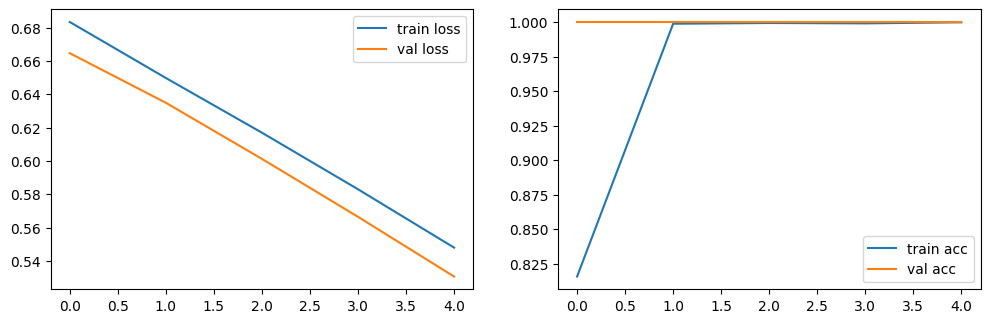

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()

y_pred = model.predict(X_train, batch_size=2)
y_pred_classes = np.argmax(y_pred, axis=1)

y_train_classes = np.argmax(y_train, axis=1)

# print("\nClassification Report:")
# print(classification_report(y_train_classes, y_pred_classes, target_names=['Class 0', 'Class 1']))

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_train_classes, y_pred_classes))

In [ ]:
training_df.to_csv("s2s.csv")

In [ ]:
training_df["labels"].head

<bound method NDFrame.head of 0     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
4     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
5     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
6     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
7     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
8     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
9     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
10    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
11    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
12    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
13    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
14    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
15    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
16    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
17    [1, 1, 1, 1,